In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, OrdinalEncoder
from imblearn.over_sampling import SMOTENC

from IPython.display import display

# Folder for all Chapter 3 figures
os.makedirs("chapter3_figures", exist_ok=True)

# Load Bank Marketing dataset
df = pd.read_csv("bank-full.csv", sep=";")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
# Missing values
null_count = df.isnull().sum().sum()

# Blank strings
object_columns = df.select_dtypes(include="object").columns

blank_count = sum(
    df[column].astype(str).str.strip().eq("").sum()
    for column in object_columns
)

# Exact duplicates
duplicate_count = df.duplicated().sum()

# Unknown categories
unknown_columns = ["job", "education", "contact", "poutcome"]

quality_data = [
    ["Missing / blank values",
     null_count + blank_count,
     ((null_count + blank_count) / len(df)) * 100],

    ["Exact duplicate records",
     duplicate_count,
     (duplicate_count / len(df)) * 100]
]

for column in unknown_columns:
    count = (df[column] == "unknown").sum()

    quality_data.append([
        f"Unknown {column}",
        count,
        count / len(df) * 100
    ])

# Special value in pdays
pdays_special = (df["pdays"] == -1).sum()

quality_data.append([
    "pdays = -1",
    pdays_special,
    pdays_special / len(df) * 100
])

quality_summary = pd.DataFrame(
    quality_data,
    columns=["Data Quality Issue", "Count", "Percentage (%)"]
)

quality_summary["Percentage (%)"] = (
    quality_summary["Percentage (%)"].round(2)
)

display(quality_summary)

,Data Quality Issue,Count,Percentage (%)
0,Missing / blank values,0,0.00
1,Exact duplicate records,0,0.00
2,Unknown job,288,0.64
3,Unknown education,1857,4.11
4,Unknown contact,13020,28.80
5,Unknown poutcome,36959,81.75
6,pdays = -1,36954,81.74


In [ ]:
numerical_columns = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

stat_summary = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Minimum": df[numerical_columns].min(),
    "Maximum": df[numerical_columns].max(),
    "Standard Deviation": df[numerical_columns].std(),
    "Skewness": df[numerical_columns].skew()
})

stat_summary = stat_summary.round(4)

display(stat_summary)

,Mean,Median,Minimum,Maximum,Standard Deviation,Skewness
age,40.9362,39.0,18,95,10.6188,0.6848
balance,1362.2721,448.0,-8019,102127,3044.7658,8.3603
day,15.8064,16.0,1,31,8.3225,0.0931
duration,258.1631,180.0,0,4918,257.5278,3.1443
campaign,2.7638,2.0,1,63,3.0980,4.8987
pdays,40.1978,-1.0,-1,871,100.1287,2.6157
previous,0.5803,0.0,0,275,2.3034,41.8465


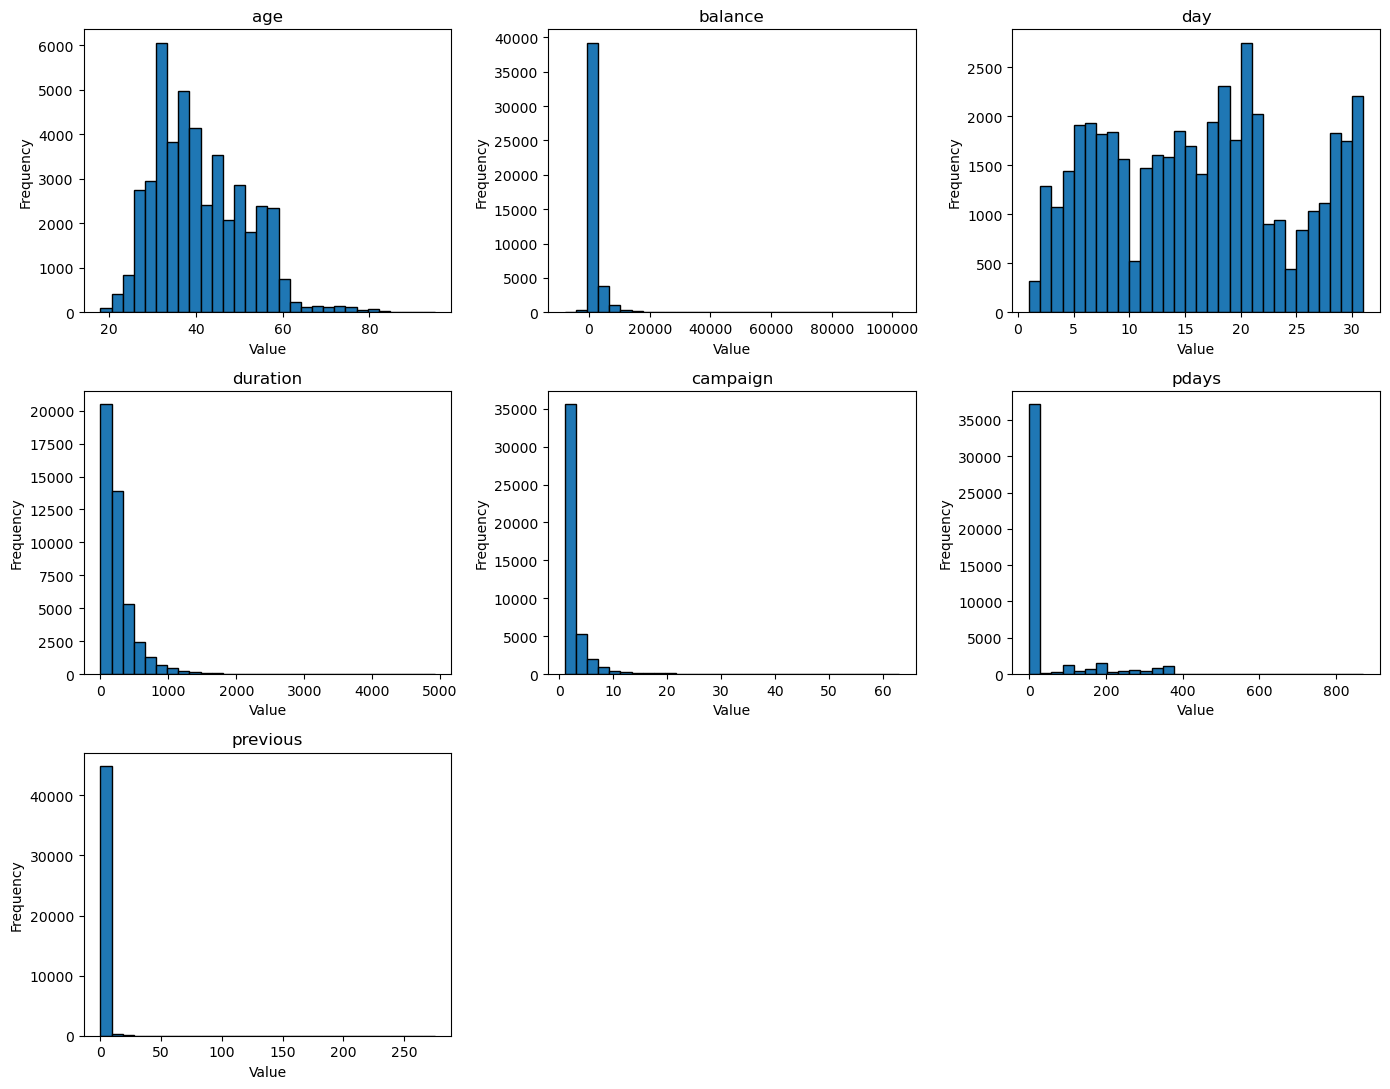

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()

for i, column in enumerate(numerical_columns):
    axes[i].hist(
        df[column],
        bins=30,
        edgecolor="black"
    )

    axes[i].set_title(column)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# Remove unused plots
for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    "chapter3_figures/Numerical_Distributions_Before.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
outlier_results = []

for column in numerical_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )

    outlier_count = outlier_mask.sum()
    outlier_percentage = (
        outlier_count / len(df) * 100
    )

    outlier_results.append([
        column,
        q1,
        q3,
        iqr,
        lower_bound,
        upper_bound,
        outlier_count,
        outlier_percentage
    ])

outlier_summary = pd.DataFrame(
    outlier_results,
    columns=[
        "Feature",
        "Q1",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Outlier Count",
        "Outlier (%)"
    ]
)

outlier_summary = outlier_summary.round(2)

display(outlier_summary)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier (%)
0,age,33.0,48.0,15.0,10.5,70.5,487,1.08
1,balance,72.0,1428.0,1356.0,-1962.0,3462.0,4729,10.46
2,day,8.0,21.0,13.0,-11.5,40.5,0,0.00
3,duration,103.0,319.0,216.0,-221.0,643.0,3235,7.16
4,campaign,1.0,3.0,2.0,-2.0,6.0,3064,6.78
5,pdays,-1.0,-1.0,0.0,-1.0,-1.0,8257,18.26
6,previous,0.0,0.0,0.0,0.0,0.0,8257,18.26


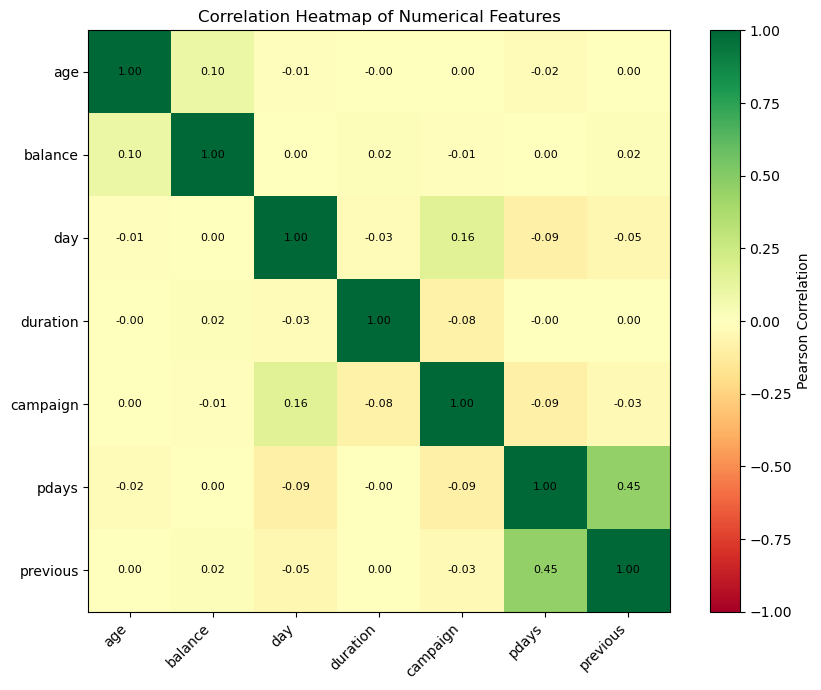

In [ ]:
correlation_matrix = df[numerical_columns].corr(method="pearson")
fig, ax = plt.subplots(figsize=(9, 7))

heatmap = ax.imshow(
    correlation_matrix,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(numerical_columns)))
ax.set_yticks(range(len(numerical_columns)))
ax.set_xticklabels(
    numerical_columns,
    rotation=45,
    ha="right"
)
ax.set_yticklabels(numerical_columns)

for i in range(len(numerical_columns)):
    for j in range(len(numerical_columns)):
        value = correlation_matrix.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

fig.colorbar(
    heatmap,
    ax=ax,
    label="Pearson Correlation"
)
ax.set_title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

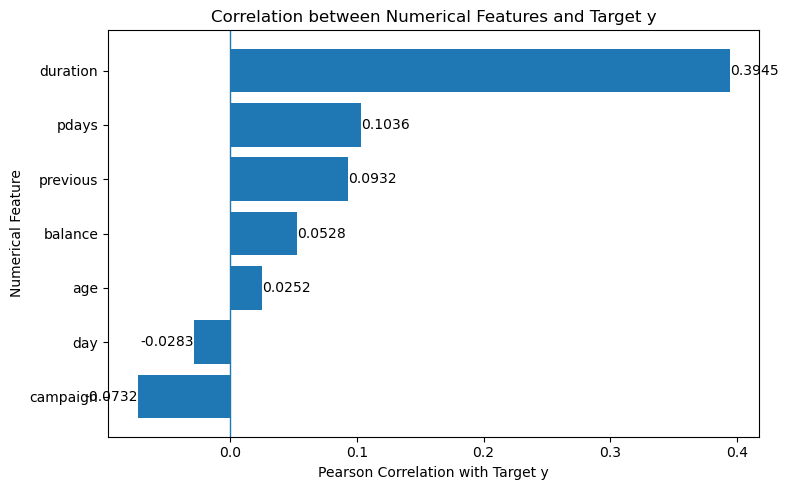

In [ ]:
df_target = df.copy()

# Convert target y into numeric form
df_target["y_numeric"] = df_target["y"].map({
    "no": 0,
    "yes": 1
})

# Calculate Pearson correlation with target y
target_correlations = (
    df_target[numerical_columns + ["y_numeric"]]
    .corr(method="pearson")["y_numeric"]
    .drop("y_numeric")
    .sort_values()
)

# Plot correlation with target y
plt.figure(figsize=(8, 5))

bars = plt.barh(
    target_correlations.index,
    target_correlations.values
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.xlabel("Pearson Correlation with Target y")
plt.ylabel("Numerical Feature")
plt.title("Correlation between Numerical Features and Target y")

for bar, value in zip(
    bars,
    target_correlations.values
):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center",
        ha="left" if value >= 0 else "right"
    )

plt.tight_layout()
plt.show()

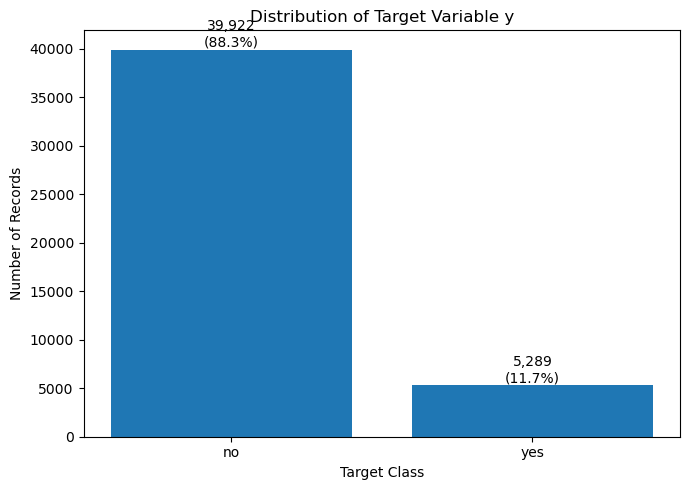

In [ ]:
class_counts = df["y"].value_counts()
class_percentages = df["y"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))

bars = plt.bar(
    class_counts.index,
    class_counts.values
)

plt.xlabel("Target Class")
plt.ylabel("Number of Records")
plt.title("Distribution of Target Variable y")

for bar, category in zip(bars, class_counts.index):
    count = class_counts[category]
    percentage = class_percentages[category]

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
noise_checks = pd.DataFrame([
    [
        "age",
        "0 or above",
        df["age"].min(),
        df["age"].max(),
        (df["age"] < 0).sum()
    ],
    [
        "day",
        "1 to 31",
        df["day"].min(),
        df["day"].max(),
        ((df["day"] < 1) | (df["day"] > 31)).sum()
    ],
    [
        "duration",
        "0 or above",
        df["duration"].min(),
        df["duration"].max(),
        (df["duration"] < 0).sum()
    ],
    [
        "campaign",
        "1 or above",
        df["campaign"].min(),
        df["campaign"].max(),
        (df["campaign"] < 1).sum()
    ],
    [
        "pdays",
        "-1 or above",
        df["pdays"].min(),
        df["pdays"].max(),
        (df["pdays"] < -1).sum()
    ],
    [
        "previous",
        "0 or above",
        df["previous"].min(),
        df["previous"].max(),
        (df["previous"] < 0).sum()
    ]
], columns=[
    "Feature",
    "Expected Range",
    "Observed Minimum",
    "Observed Maximum",
    "Invalid Value Count"
])

display(noise_checks)

,Feature,Expected Range,Observed Minimum,Observed Maximum,Invalid Value Count
0,age,0 or above,18,95,0
1,day,1 to 31,1,31,0
2,duration,0 or above,0,4918,0
3,campaign,1 or above,1,63,0
4,pdays,-1 or above,-1,871,0
5,previous,0 or above,0,275,0


In [ ]:
categorical_columns = df.select_dtypes(include="object").columns

consistency_results = []

for column in categorical_columns:
    unique_values = sorted(df[column].dropna().unique())

    consistency_results.append([
        column,
        len(unique_values),
        ", ".join(unique_values)
    ])

consistency_summary = pd.DataFrame(
    consistency_results,
    columns=[
        "Feature",
        "Number of Unique Categories",
        "Observed Categories"
    ]
)

display(consistency_summary)

,Feature,Number of Unique Categories,Observed Categories
0,job,12,"admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown"
1,marital,3,"divorced, married, single"
2,education,4,"primary, secondary, tertiary, unknown"
3,default,2,"no, yes"
4,housing,2,"no, yes"
5,loan,2,"no, yes"
6,contact,3,"cellular, telephone, unknown"
7,month,12,"apr, aug, dec, feb, jan, jul, jun, mar, may, nov, oct, sep"
8,poutcome,4,"failure, other, success, unknown"
9,y,2,"no, yes"
